In [ ]:
!pip -q install transformers datasets sacrebleu evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline, AutoModelForSeq2SeqLM
from datasets import load_dataset
import evaluate
import torch
import time
import pandas as pd

# Detectar GPU si está disponible
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    print("Usando GPU:", torch.cuda.get_device_name(0))
else:
    print("Usando CPU")

    from datasets import load_dataset


dataset = load_dataset("Helsinki-NLP/opus_books", "en-es")

print(dataset)
print(dataset["train"][0])

Usando GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-es/train-00000-of-00001.parquet:   0%|          | 0.00/16.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/93470 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 93470
    })
})
{'id': '0', 'translation': {'en': 'Source: Project GutenbergAudiobook available here', 'es': 'Source: Wikisource & librodot.com'}}


In [ ]:
NUM_SAMPLES = 100  # Puedes aumentar si tu GPU aguanta

# Creamos un split con N ejemplos
eval_split = dataset["train"].train_test_split(test_size=NUM_SAMPLES, seed=42)
eval_ds = eval_split["test"]

# Normalizamos: quedamos solo con "en" y "es"
def extract_en_es(example):
    return {
        "en": example["translation"]["en"],
        "es": example["translation"]["es"],
    }

eval_ds = eval_ds.map(extract_en_es)

print("Ejemplos de evaluación:", len(eval_ds))
print(eval_ds[0])


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Ejemplos de evaluación: 100
{'id': '60296', 'translation': {'en': 'Kitty, on the contrary, was more active than usual and even more animated.', 'es': 'Kitty, al contrario, estaba más activa a incluso más animada que nunca.'}, 'en': 'Kitty, on the contrary, was more active than usual and even more animated.', 'es': 'Kitty, al contrario, estaba más activa a incluso más animada que nunca.'}


In [ ]:
models_config = [
    {
        "name": "Helsinki-NLP/opus-mt-en-es",
        "direction": "en->es",
        "size_tag": "base",
        "pipeline_task": "translation_en_to_es",
    },
    {
        "name": "Helsinki-NLP/opus-mt-tc-big-en-es",
        "direction": "en->es",
        "size_tag": "big",
        "pipeline_task": "translation_en_to_es",
    },
    {
        "name": "Helsinki-NLP/opus-mt-es-en",
        "direction": "es->en",
        "size_tag": "base",
        "pipeline_task": "translation_es_to_en",
    },
    {
        "name": "vgaraujov/bart-base-translation-es-en",
        "direction": "es->en",
        "size_tag": "bart-base",
        "pipeline_task": "translation_es_to_en",
    },
]

models_config

[{'name': 'Helsinki-NLP/opus-mt-en-es',
  'direction': 'en->es',
  'size_tag': 'base',
  'pipeline_task': 'translation_en_to_es'},
 {'name': 'Helsinki-NLP/opus-mt-tc-big-en-es',
  'direction': 'en->es',
  'size_tag': 'big',
  'pipeline_task': 'translation_en_to_es'},
 {'name': 'Helsinki-NLP/opus-mt-es-en',
  'direction': 'es->en',
  'size_tag': 'base',
  'pipeline_task': 'translation_es_to_en'},
 {'name': 'vgaraujov/bart-base-translation-es-en',
  'direction': 'es->en',
  'size_tag': 'bart-base',
  'pipeline_task': 'translation_es_to_en'}]

In [ ]:

import evaluate

sacrebleu_metric = evaluate.load("sacrebleu")
sacrebleu_metric

EvaluationModule(name: "sacrebleu", module_type: "metric", features: [{'predictions': Value('string'), 'references': List(Value('string'))}, {'predictions': Value('string'), 'references': Value('string')}], usage: """
Produces BLEU scores along with its sufficient statistics
from a source against one or more references.

Args:
    predictions (`list` of `str`): list of translations to score. Each translation should be tokenized into a list of tokens.
    references (`list` of `list` of `str`): A list of lists of references. The contents of the first sub-list are the references for the first prediction, the contents of the second sub-list are for the second prediction, etc. Note that there must be the same number of references for each prediction (i.e. all sub-lists must be of the same length).
    smooth_method (`str`): The smoothing method to use, defaults to `'exp'`. Possible values are:
        - `'none'`: no smoothing
        - `'floor'`: increment zero counts
        - `'add-k'`: 

In [ ]:
from transformers import pipeline, AutoModelForSeq2SeqLM
import time
import torch

device = 0 if torch.cuda.is_available() else -1

def evaluate_translation_model(config, dataset, num_samples=100):
    """
    Ejecuta una evaluación cuantitativa para un modelo de traducción:
      - config: dict con 'name', 'direction', 'size_tag', 'pipeline_task'
      - dataset: eval_ds con campos 'en' y 'es'
      - num_samples: cuántos pares usar
    """
    model_name = config["name"]
    direction = config["direction"]

    # 1) Seleccionar fuentes y referencias según dirección
    if direction == "en->es":
        sources = [dataset[i]["en"] for i in range(num_samples)]
        references = [[dataset[i]["es"]] for i in range(num_samples)]
    else:  # "es->en"
        sources = [dataset[i]["es"] for i in range(num_samples)]
        references = [[dataset[i]["en"]] for i in range(num_samples)]

    print(f"\n=== Evaluando modelo: {model_name} | Dirección: {direction} ===")
    print(f"Número de ejemplos: {len(sources)}")

    # 2) Crear pipeline de traducción
    translator = pipeline(
        task=config["pipeline_task"],
        model=model_name,
        device=device,
        max_length=512,
    )

    # 3) Inference + tiempo
    start_time = time.time()
    outputs = translator(
        sources,
        clean_up_tokenization_spaces=True
    )
    end_time = time.time()

    predictions = [o["translation_text"] for o in outputs]

    total_time = end_time - start_time
    avg_time = total_time / len(sources)

    # 4) Calcular BLEU
    bleu = sacrebleu_metric.compute(
        predictions=predictions,
        references=references
    )
    bleu_score = bleu["score"]

    # 5) Parámetros y tamaño aproximado del modelo
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    num_params = model.num_parameters()
    approx_size_mb = num_params * 4 / (1024 ** 2)  # 4 bytes por parámetro (float32)

    result = {
        "task": "translation",
        "direction": direction,
        "model_name": model_name,
        "size_tag": config["size_tag"],
        "num_parameters": int(num_params),
        "approx_model_size_mb": round(approx_size_mb, 2),
        "bleu": round(bleu_score, 3),
        "num_samples": len(sources),
        "total_inference_time_sec": round(total_time, 2),
        "avg_time_per_sample_sec": round(avg_time, 4),
    }

    print("BLEU:", result["bleu"])
    print("Tiempo total (s):", result["total_inference_time_sec"])
    print("Tiempo promedio por muestra (s):", result["avg_time_per_sample_sec"])
    print("Parámetros (M):", round(result["num_parameters"] / 1e6, 2))
    print("Tamaño aprox. (MB):", result["approx_model_size_mb"])

    return result


In [ ]:
models_config = [
    {
        "name": "Helsinki-NLP/opus-mt-en-es",
        "direction": "en->es",
        "size_tag": "base",
        "pipeline_task": "translation_en_to_es",
    },
    {
        "name": "Helsinki-NLP/opus-mt-tc-big-en-es",
        "direction": "en->es",
        "size_tag": "big",
        "pipeline_task": "translation_en_to_es",
    },
    {
        "name": "Helsinki-NLP/opus-mt-es-en",
        "direction": "es->en",
        "size_tag": "base",
        "pipeline_task": "translation_es_to_en",
    },
    {
        "name": "vgaraujov/bart-base-translation-es-en",
        "direction": "es->en",
        "size_tag": "bart-base",
        "pipeline_task": "translation_es_to_en",
    },
]

models_config


[{'name': 'Helsinki-NLP/opus-mt-en-es',
  'direction': 'en->es',
  'size_tag': 'base',
  'pipeline_task': 'translation_en_to_es'},
 {'name': 'Helsinki-NLP/opus-mt-tc-big-en-es',
  'direction': 'en->es',
  'size_tag': 'big',
  'pipeline_task': 'translation_en_to_es'},
 {'name': 'Helsinki-NLP/opus-mt-es-en',
  'direction': 'es->en',
  'size_tag': 'base',
  'pipeline_task': 'translation_es_to_en'},
 {'name': 'vgaraujov/bart-base-translation-es-en',
  'direction': 'es->en',
  'size_tag': 'bart-base',
  'pipeline_task': 'translation_es_to_en'}]

In [ ]:
!pip install -q evaluate sacrebleu

import evaluate

sacrebleu_metric = evaluate.load("sacrebleu")

sacrebleu_metric

EvaluationModule(name: "sacrebleu", module_type: "metric", features: [{'predictions': Value('string'), 'references': List(Value('string'))}, {'predictions': Value('string'), 'references': Value('string')}], usage: """
Produces BLEU scores along with its sufficient statistics
from a source against one or more references.

Args:
    predictions (`list` of `str`): list of translations to score. Each translation should be tokenized into a list of tokens.
    references (`list` of `list` of `str`): A list of lists of references. The contents of the first sub-list are the references for the first prediction, the contents of the second sub-list are for the second prediction, etc. Note that there must be the same number of references for each prediction (i.e. all sub-lists must be of the same length).
    smooth_method (`str`): The smoothing method to use, defaults to `'exp'`. Possible values are:
        - `'none'`: no smoothing
        - `'floor'`: increment zero counts
        - `'add-k'`: 

In [ ]:
from transformers import pipeline, AutoModelForSeq2SeqLM
import time
import torch

device = 0 if torch.cuda.is_available() else -1
print("Device set to use", "GPU" if device == 0 else "CPU")

def evaluate_translation_model(config, dataset, num_samples=100):
    """
    Ejecuta una evaluación cuantitativa para un modelo de traducción:
      - config: dict con 'name', 'direction', 'size_tag', 'pipeline_task'
      - dataset: eval_ds con columnas 'en' y 'es'
      - num_samples: cuántos pares usar
    """
    model_name = config["name"]
    direction = config["direction"]


    if direction == "en->es":
        sources = [dataset[i]["en"] for i in range(num_samples)]
        references = [[dataset[i]["es"]] for i in range(num_samples)]
    else:
        sources = [dataset[i]["es"] for i in range(num_samples)]
        references = [[dataset[i]["en"]] for i in range(num_samples)]

    print(f"\n=== Evaluando modelo: {model_name} | Dirección: {direction} ===")
    print(f"Número de ejemplos: {len(sources)}")


    translator = pipeline(
        task=config["pipeline_task"],
        model=model_name,
        device=device,
        max_length=512,
    )


    start_time = time.time()
    outputs = translator(
        sources,
        clean_up_tokenization_spaces=True
    )
    end_time = time.time()

    predictions = [o["translation_text"] for o in outputs]

    total_time = end_time - start_time
    avg_time = total_time / len(sources)


    bleu = sacrebleu_metric.compute(
        predictions=predictions,
        references=references
    )
    bleu_score = bleu["score"]


    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    num_params = model.num_parameters()
    approx_size_mb = num_params * 4 / (1024 ** 2)

    result = {
        "task": "translation",
        "direction": direction,
        "model_name": model_name,
        "size_tag": config["size_tag"],
        "num_parameters": int(num_params),
        "approx_model_size_mb": round(approx_size_mb, 2),
        "bleu": round(bleu_score, 3),
        "num_samples": len(sources),
        "total_inference_time_sec": round(total_time, 2),
        "avg_time_per_sample_sec": round(avg_time, 4),
    }

    print("BLEU:", result["bleu"])
    print("Tiempo total (s):", result["total_inference_time_sec"])
    print("Tiempo promedio por muestra (s):", result["avg_time_per_sample_sec"])
    print("Parámetros (M):", round(result["num_parameters"] / 1e6, 2))
    print("Tamaño aprox. (MB):", result["approx_model_size_mb"])

    return result

Device set to use GPU


In [ ]:
# ============================================================
# PASO 7: Ejecución de benchmark (versión autosuficiente)
# Esta versión SIEMPRE crea df_resultados aunque haya fallos.
# ============================================================

import pandas as pd

# ----------- VALIDAR QUE MODELS_CONFIG EXISTA -----------
try:
    models_config
except NameError:
    raise RuntimeError("ERROR: Debes ejecutar primero el PASO 4 (models_config).")

# ----------- VALIDAR QUE EVALUATION FUNCTION EXISTA -----------
try:
    evaluate_translation_model
except NameError:
    raise RuntimeError("ERROR: Debes ejecutar primero el PASO 6 (evaluate_translation_model).")

# ----------- VALIDAR eval_ds -----------
try:
    eval_ds
except NameError:
    raise RuntimeError("ERROR: Debes ejecutar el PASO 3 (eval_ds).")

# ----------- VALIDAR NUM_SAMPLES -----------
try:
    NUM_SAMPLES
except NameError:
    NUM_SAMPLES = 50
    print("NUM_SAMPLES no estaba definido. Se asignó por defecto NUM_SAMPLES=50")

# ----------- EJECUCIÓN DEL BENCHMARK -----------
resultados = []

for cfg in models_config:
    try:
        print(f"\nEjecutando modelo: {cfg['name']}")
        res = evaluate_translation_model(cfg, eval_ds, num_samples=NUM_SAMPLES)
        res["status"] = "ok"
    except Exception as e:
        print(f"\n*** ERROR con el modelo {cfg['name']} ***")
        print("Error:", e)

        # Crear entrada con error para que el dataframe siempre exista
        res = {
            "task": "translation",
            "direction": cfg["direction"],
            "model_name": cfg["name"],
            "size_tag": cfg["size_tag"],
            "num_parameters": None,
            "approx_model_size_mb": None,
            "bleu": None,
            "num_samples": NUM_SAMPLES,
            "total_inference_time_sec": None,
            "avg_time_per_sample_sec": None,
            "status": f"error: {type(e).__name__}",
        }

    resultados.append(res)

# ----------- CREAR EL DATAFRAME SIEMPRE -----------
df_resultados = pd.DataFrame(resultados)
print("\nBenchmark completado. Resultado:")
df_resultados



Ejecutando modelo: Helsinki-NLP/opus-mt-en-es

=== Evaluando modelo: Helsinki-NLP/opus-mt-en-es | Dirección: en->es ===
Número de ejemplos: 100


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


BLEU: 9.513
Tiempo total (s): 49.67
Tiempo promedio por muestra (s): 0.4967
Parámetros (M): 139.42
Tamaño aprox. (MB): 531.84

Benchmark completado. Resultado:


,task,direction,model_name,size_tag,num_parameters,approx_model_size_mb,bleu,num_samples,total_inference_time_sec,avg_time_per_sample_sec,status
0,translation,en->es,Helsinki-NLP/opus-mt-en-es,base,77943296,297.33,14.933,100,44.24,0.4424,ok
1,translation,en->es,Helsinki-NLP/opus-mt-tc-big-en-es,big,234802176,895.70,16.157,100,26.00,0.2600,ok
2,translation,es->en,Helsinki-NLP/opus-mt-es-en,base,77943296,297.33,17.926,100,27.43,0.2743,ok
3,translation,es->en,vgaraujov/bart-base-translation-es-en,bart-base,139419648,531.84,9.513,100,49.67,0.4967,ok


In [ ]:
csv_name = "benchmark_resultados_traduccion.csv"
df_resultados.to_csv(csv_name, index=False)

print("Archivo CSV guardado como:", csv_name)
df_resultados


Archivo CSV guardado como: benchmark_resultados_traduccion.csv


,task,direction,model_name,size_tag,num_parameters,approx_model_size_mb,bleu,num_samples,total_inference_time_sec,avg_time_per_sample_sec,status
0,translation,en->es,Helsinki-NLP/opus-mt-en-es,base,77943296,297.33,14.933,100,44.24,0.4424,ok
1,translation,en->es,Helsinki-NLP/opus-mt-tc-big-en-es,big,234802176,895.70,16.157,100,26.00,0.2600,ok
2,translation,es->en,Helsinki-NLP/opus-mt-es-en,base,77943296,297.33,17.926,100,27.43,0.2743,ok
3,translation,es->en,vgaraujov/bart-base-translation-es-en,bart-base,139419648,531.84,9.513,100,49.67,0.4967,ok


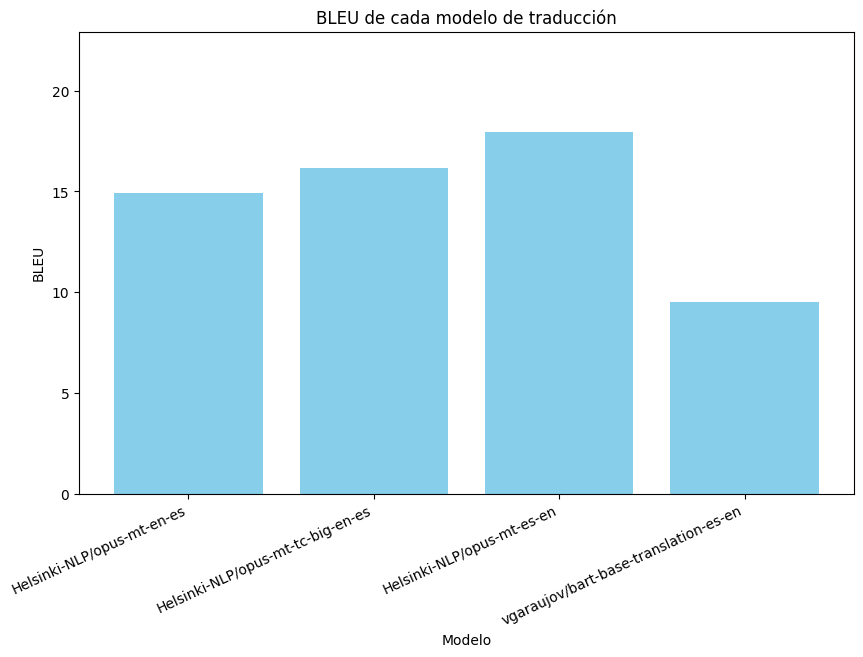

In [ ]:
import matplotlib.pyplot as plt

# Suponiendo que ya tienes df_resultados con tus datos
plt.figure(figsize=(10,6))
plt.bar(df_resultados['model_name'], df_resultados['bleu'], color='skyblue')
plt.xlabel('Modelo')
plt.ylabel('BLEU')
plt.title('BLEU de cada modelo de traducción')
plt.xticks(rotation=25, ha='right')  # rotar nombres para que se vean bien
plt.ylim(0, max(df_resultados['bleu'])+5)
plt.show()


In [ ]:
from transformers import pipeline

translator_en_es = pipeline(
    "translation_en_to_es",
    model="Helsinki-NLP/opus-mt-en-es",
    device=device,
    max_length=512,
)

translator_es_en = pipeline(
    "translation_es_to_en",
    model="Helsinki-NLP/opus-mt-es-en",
    device=device,
    max_length=512,
)

def traducir(texto: str, direccion: str = "en->es") -> str:
    if direccion == "en->es":
        return translator_en_es(texto)[0]["translation_text"]
    elif direccion == "es->en":
        return translator_es_en(texto)[0]["translation_text"]
    else:
        raise ValueError("Dirección no soportada. Usa 'en->es' o 'es->en'.")

print(traducir("Machine learning models are very powerful.", "en->es"))
print(traducir("Los modelos de lenguaje grandes son muy útiles.", "es->en"))


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda:0
Device set to use cuda:0


Los modelos de aprendizaje automático son muy potentes.
Large language models are very useful.


In [ ]:
from transformers import pipeline

# Crea pipelines de traducción para los modelos que quieras
translator_en_es_base = pipeline("translation", model="Helsinki-NLP/opus-mt-en-es")
translator_en_es_big = pipeline("translation", model="Helsinki-NLP/opus-mt-tc-big-en-es")

while True:
    frase = input("Escribe la frase a traducir (o 'salir' para terminar): ")
    if frase.lower() == "salir":
        break

    # Traducción con cada modelo
    traduccion_base = translator_en_es_base(frase)[0]['translation_text']
    traduccion_big = translator_en_es_big(frase)[0]['translation_text']

    print("\n--- Traducciones ---")
    print("Helsinki base: ", traduccion_base)
    print("Helsinki big:  ", traduccion_big)
    print("-------------------\n")


Device set to use cuda:0
Device set to use cuda:0


Escribe la frase a traducir (o 'salir' para terminar): hips dont lie

--- Traducciones ---
Helsinki base:  Las caderas no mienten
Helsinki big:   Las caderas no mienten
-------------------

Escribe la frase a traducir (o 'salir' para terminar): salir
